# 📊 Análisis Bivariado: Numérico vs. Categórico

Este notebook realiza un análisis exploratorio de datos (EDA) enfocado en la relación entre variables numéricas continuas y variables categóricas.

**Incluye:**
- Boxplots y Violin Plots.
- Pruebas estadísticas: T-test (2 grupos) y ANOVA (>2 grupos).
- Interpretación de significancia estadística.

In [1]:
# 1. Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

# Configuración de estilo
sns.set(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [3]:
# 2. Carga de Datos
# Asegúrate de que el archivo 'train_processed.csv' esté en la misma carpeta que este notebook
filename = r'C:\Users\Ing. Antonio Rial\OneDrive - Universidad Austral\MCD_Laboratorio.de.Implementación.2\Competencia.House.Pricing\data\tabular\train_processed.csv'

if os.path.exists(filename):
    df = pd.read_csv(filename)
    print(f"📄 Archivo '{filename}' cargado exitosamente.")
    print(f"📏 Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
    df.head()
else:
    print(f"⚠️ No se encontró el archivo '{filename}'.")
    print("Por favor, coloca el archivo CSV en la misma carpeta que este notebook.")

📄 Archivo 'C:\Users\Ing. Antonio Rial\OneDrive - Universidad Austral\MCD_Laboratorio.de.Implementación.2\Competencia.House.Pricing\data\tabular\train_processed.csv' cargado exitosamente.
📏 Dimensiones del dataset: 11840 filas x 46 columnas


In [4]:
# 3. Preprocesamiento Básico
if 'df' in locals():
    # Identificar tipos de datos
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Filtrar columnas categóricas con demasiadas categorías únicas (evitar ruido)
    # Mantenemos solo aquellas con entre 2 y 8 categorías únicas para que los gráficos sean legibles
    valid_cat_cols = []
    for col in categorical_cols:
        n_unique = df[col].nunique()
        if 2 <= n_unique <= 8:
            valid_cat_cols.append(col)

    # Seleccionamos las primeras 5 variables numéricas para el análisis (puedes cambiar esto)
    target_numeric_cols = numeric_cols[:5]

    print(f"🔢 Variables Numéricas a analizar: {target_numeric_cols}")
    print(f"🏷️ Variables Categóricas válidas (2-8 clases): {valid_cat_cols}")
else:
    print("Por favor, ejecuta la celda de carga de datos primero.")

🔢 Variables Numéricas a analizar: ['zpid', 'lastSoldPrice_hpi_adjusted', 'log_price', 'bedrooms', 'bathrooms']
🏷️ Variables Categóricas válidas (2-8 clases): ['homeType']


In [5]:
# 4. Función para Análisis Bivariado y Pruebas Estadísticas

def analyze_and_plot(df, num_col, cat_col):
    """
    Realiza visualización y prueba estadística entre una columna numérica y una categórica.
    """
    # Eliminar filas con nulos en las columnas de interés
    data_clean = df[[num_col, cat_col]].dropna()
    
    if data_clean.empty:
        return None

    # Obtener grupos únicos
    groups = [group[num_col].values for name, group in data_clean.groupby(cat_col)]
    group_names = [name for name, group in data_clean.groupby(cat_col)]
    
    # Determinar prueba estadística
    n_groups = len(groups)
    stat_test_name = ""
    p_value = np.nan
    
    if n_groups == 2:
        # T-test independiente
        stat, p_value = stats.ttest_ind(*groups, nan_policy='omit')
        stat_test_name = "T-test"
    elif n_groups > 2:
        # One-way ANOVA
        stat, p_value = stats.f_oneway(*groups)
        stat_test_name = "ANOVA"
    else:
        return None

    # Visualización: Boxplot + Violin Plot lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Gráfico 1: Boxplot
    sns.boxplot(x=cat_col, y=num_col, data=data_clean, ax=axes[0], palette="viridis")
    axes[0].set_title(f"Boxplot: {num_col} vs {cat_col}", fontsize=14)
    axes[0].tick_params(axis='x', rotation=45)

    # Gráfico 2: Violin Plot
    sns.violinplot(x=cat_col, y=num_col, data=data_clean, ax=axes[1], palette="magma", inner="quartile")
    axes[1].set_title(f"Violin Plot: {num_col} vs {cat_col}", fontsize=14)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

    return {
        "Variable Numérica": num_col,
        "Variable Categórica": cat_col,
        "Grupos": n_groups,
        "Prueba": stat_test_name,
        "P-valor": p_value,
        "Significativo (α=0.05)": "Sí ✅" if p_value < 0.05 else "No ❌"
    }

Analizando relaciones para las variables numéricas: ['zpid', 'lastSoldPrice_hpi_adjusted', 'log_price', 'bedrooms', 'bathrooms']
--------------------------------------------------


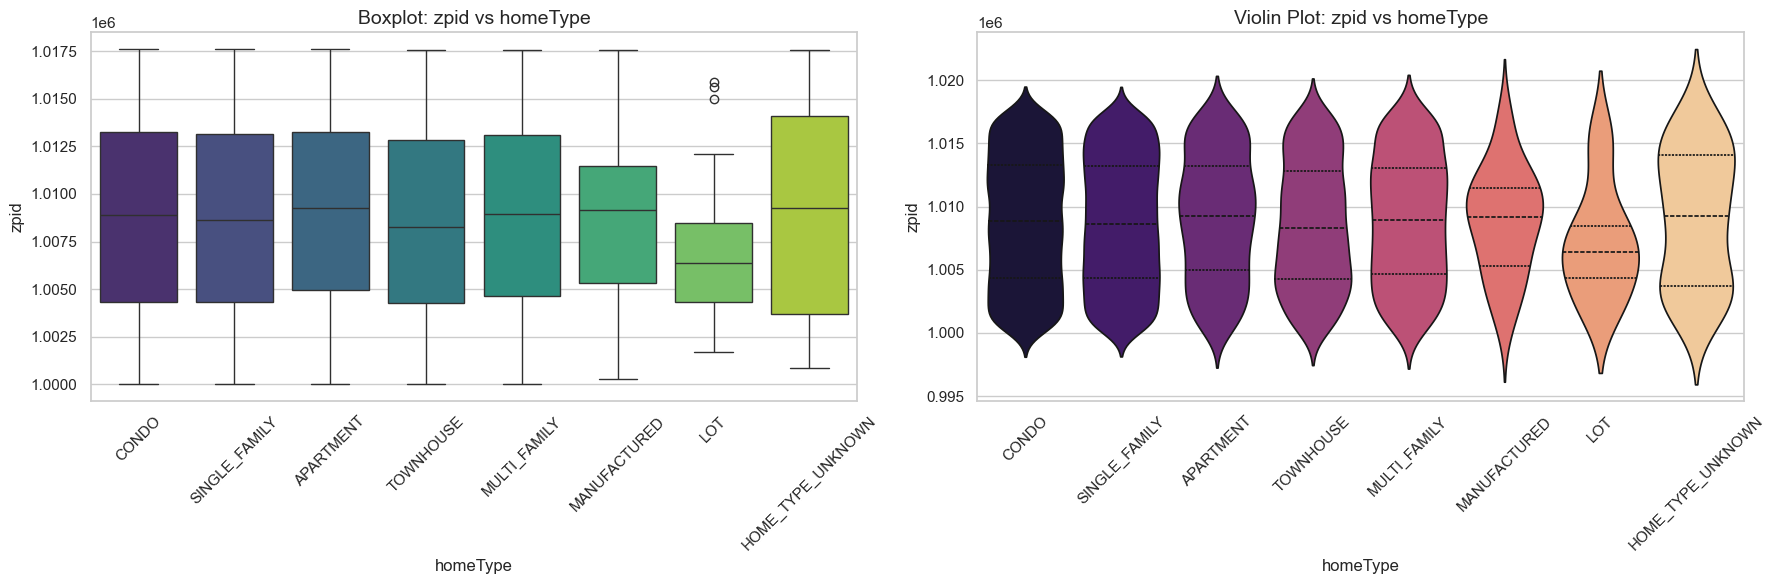

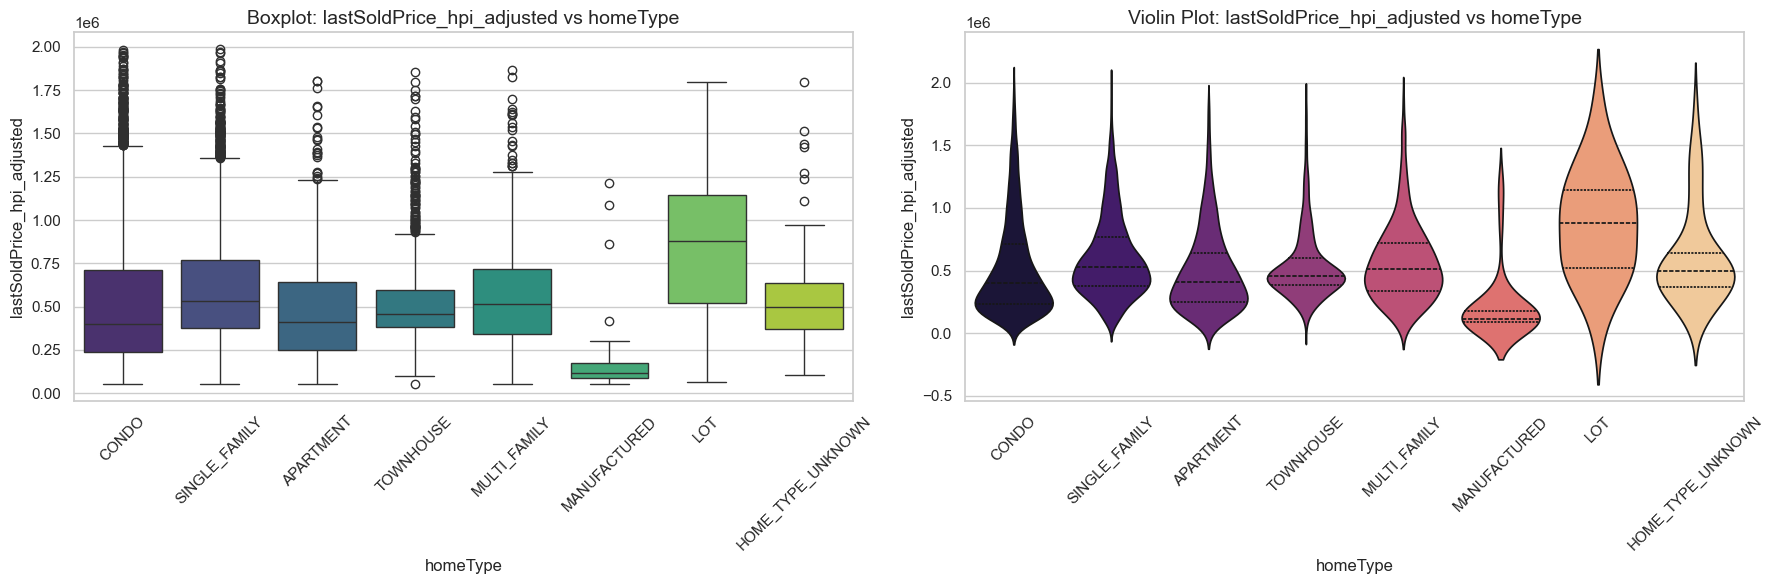

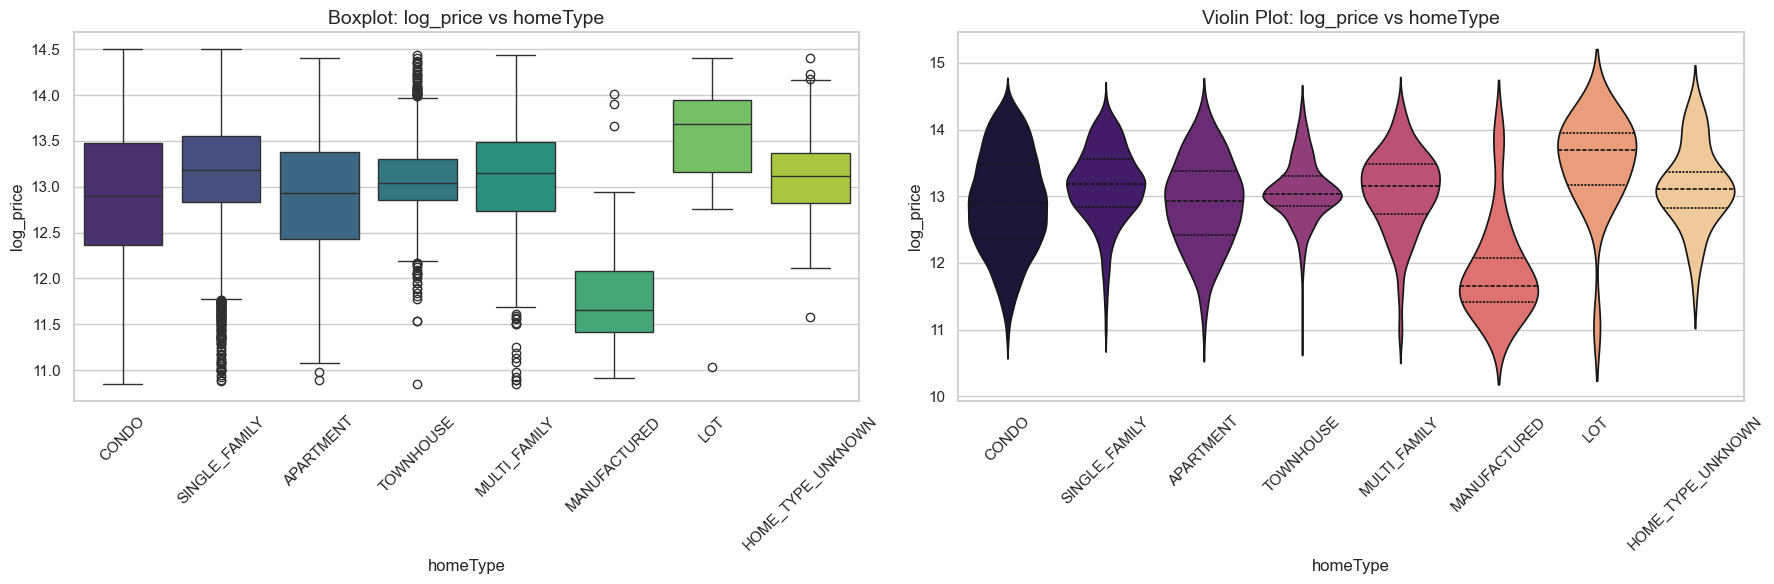

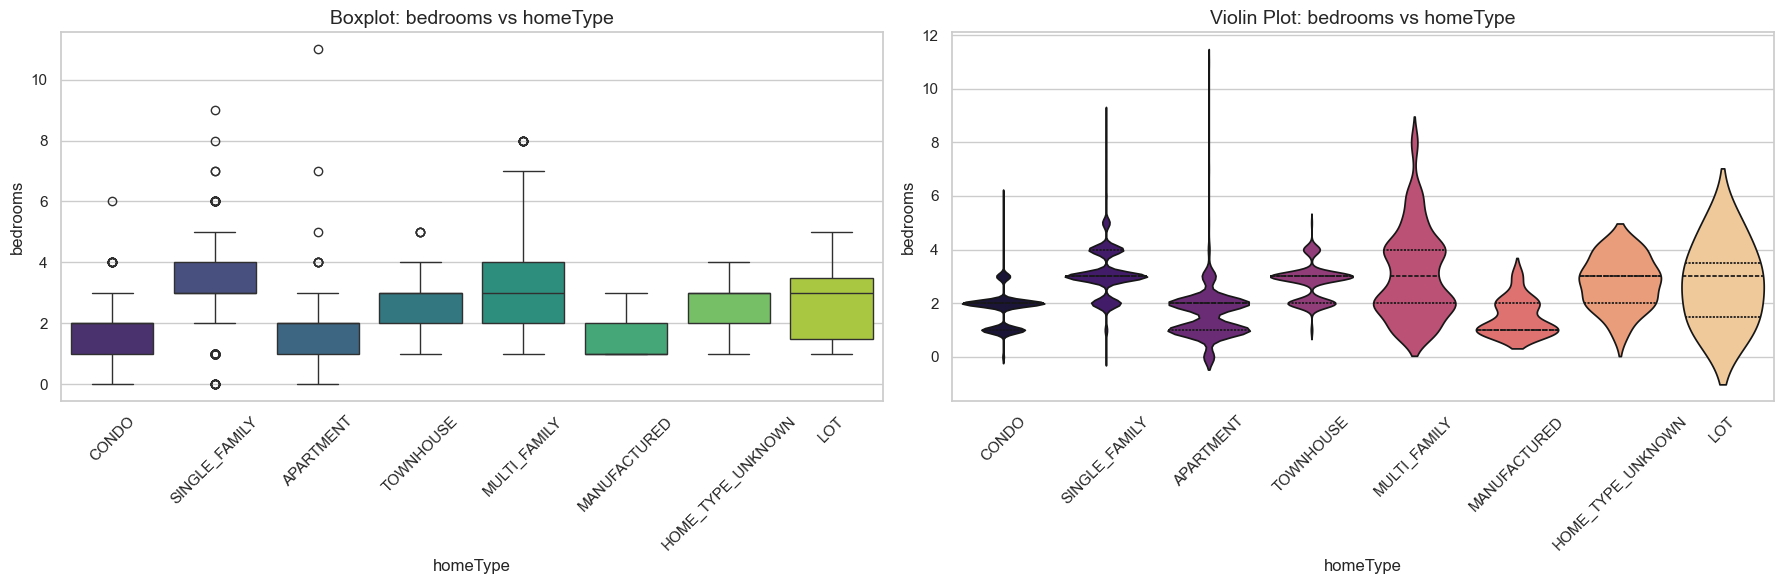

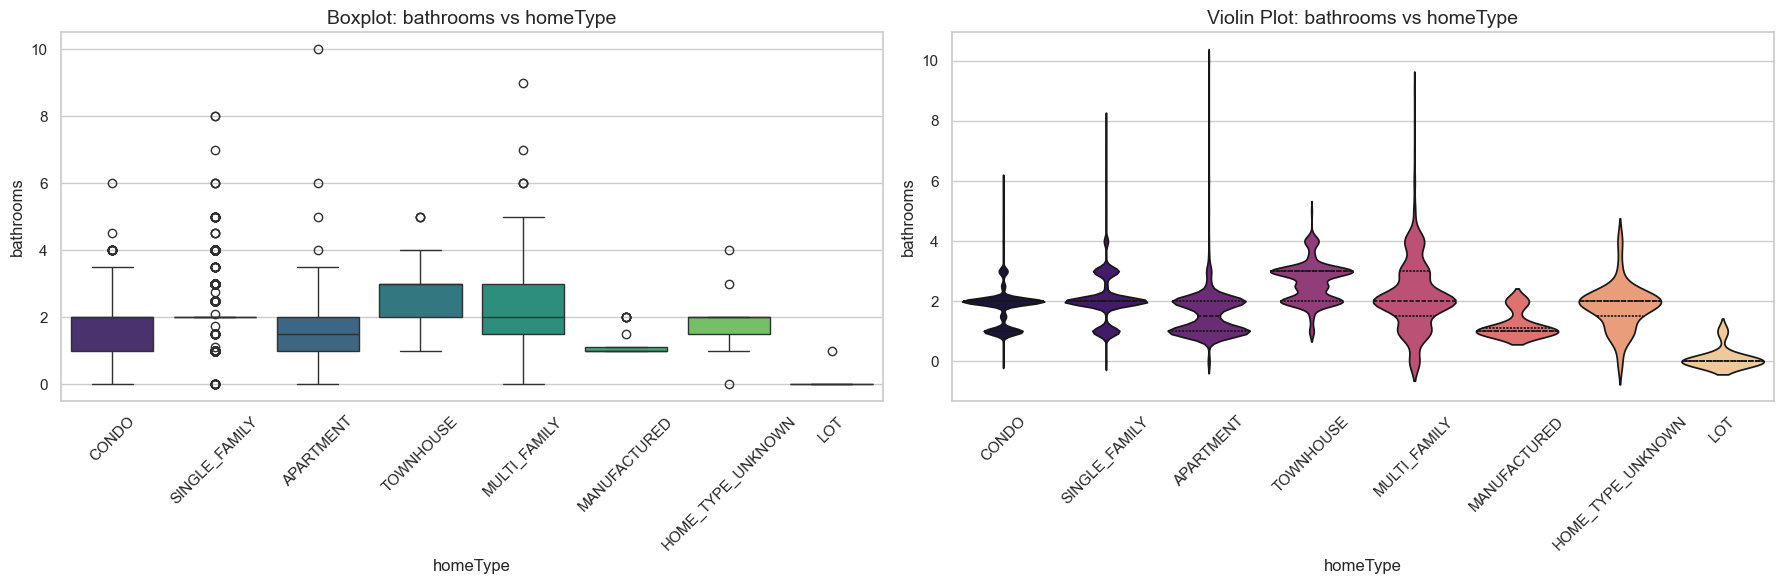

,Variable Numérica,Variable Categórica,Grupos,Prueba,P-valor,Significativo (α=0.05)
3,bedrooms,homeType,8,ANOVA,0.000000e+00,Sí ✅
4,bathrooms,homeType,8,ANOVA,8.072823e-315,Sí ✅
2,log_price,homeType,8,ANOVA,1.815713e-108,Sí ✅
1,lastSoldPrice_hpi_adjusted,homeType,8,ANOVA,1.791697e-40,Sí ✅
0,zpid,homeType,8,ANOVA,3.722698e-01,No ❌


In [6]:
# 5. Ejecución del Análisis

if 'df' in locals() and 'target_numeric_cols' in locals():
    results = []
    
    print(f"Analizando relaciones para las variables numéricas: {target_numeric_cols}")
    print("-" * 50)

    for num_col in target_numeric_cols:
        for cat_col in valid_cat_cols:
            res = analyze_and_plot(df, num_col, cat_col)
            if res:
                results.append(res)

    # Crear DataFrame de resultados estadísticos
    if results:
        df_results = pd.DataFrame(results)
        display(df_results.sort_values(by='P-valor'))
    else:
        print("No se generaron resultados válidos.")

else:
    print("Error: Asegúrate de haber ejecutado las celdas de carga y preprocesamiento primero.")

### Interpretación de Resultados

- **P-valor < 0.05**: Existe evidencia estadística suficiente para rechazar la hipótesis nula. Esto sugiere que **sí hay diferencias significativas** en la media de la variable numérica entre los distintos grupos de la variable categórica.
- **P-valor >= 0.05**: No hay evidencia suficiente para afirmar que existan diferencias significativas entre los grupos.